In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train=pd.read_csv("train.csv")

In [3]:
import matplotlib.pyplot as plt

# 전체 그래프에서 축 숫자를 안 보이게 설정
plt.rcParams['ytick.left'] = False
plt.rcParams['ytick.labelleft'] = False

In [4]:
train.head();

In [5]:
# -------------------- 매장/메뉴 분리 --------------------
store_names = ['느티나무', '담하', '라그로타', '미라시아', '연회장', '카페테리아', '포레스트릿', '화담숲주막', '화담숲카페']

def extract_store_and_menu(full_name, store_names):
    for store in store_names:
        if full_name.startswith(store):
            # 1) 매장명 길이만큼 잘라내고, 공백과 언더바(_) 제거
            menu = full_name[len(store):].strip().replace('_', '')
            
            # 2) '매장명(store)' 자체와 메뉴를 리턴
            return store, menu
            
    # 3) 만약 리스트에 없는 이상한 매장명이 들어오면 '기타'로 묶기
    return '기타', full_name

영업장명_메뉴명 컬럼의 '매장_메뉴' 형태를 데이터 분석을 용이하게 하기 위해
매장명, 메뉴명으로 깔끔하게 분리시켰다. 

In [6]:
# '매장명'과 '메뉴명'이라는 2개의 새로운 열 생성
train[['매장명', '메뉴명']] = train['영업장명_메뉴명'].apply(
    lambda x: pd.Series(extract_store_and_menu(x, store_names))
)

train=train.drop('영업장명_메뉴명',axis=1)

In [7]:
# 결과 확인
train.head();

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102676 entries, 0 to 102675
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   영업일자    102676 non-null  object
 1   매출수량    102676 non-null  int64 
 2   매장명     102676 non-null  object
 3   메뉴명     102676 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.1+ MB


'영업일자' 컬럼을 요일,월단위로 세분화하여 분석하기 위해 datetime 타입으로 바꾸었다.

In [9]:
train['영업일자'] = pd.to_datetime(train['영업일자'])

day_dict = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
train['요일'] = train['영업일자'].dt.weekday.map(day_dict)

train['월'] = train['영업일자'].dt.month
train['매출수량'] = train['매출수량'].apply(lambda x:max(x,0))

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102676 entries, 0 to 102675
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   영업일자    102676 non-null  datetime64[ns]
 1   매출수량    102676 non-null  int64         
 2   매장명     102676 non-null  object        
 3   메뉴명     102676 non-null  object        
 4   요일      102676 non-null  object        
 5   월       102676 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(3)
memory usage: 4.3+ MB


In [11]:
train.isna().sum()

영업일자    0
매출수량    0
매장명     0
메뉴명     0
요일      0
월       0
dtype: int64

In [12]:
train.head();

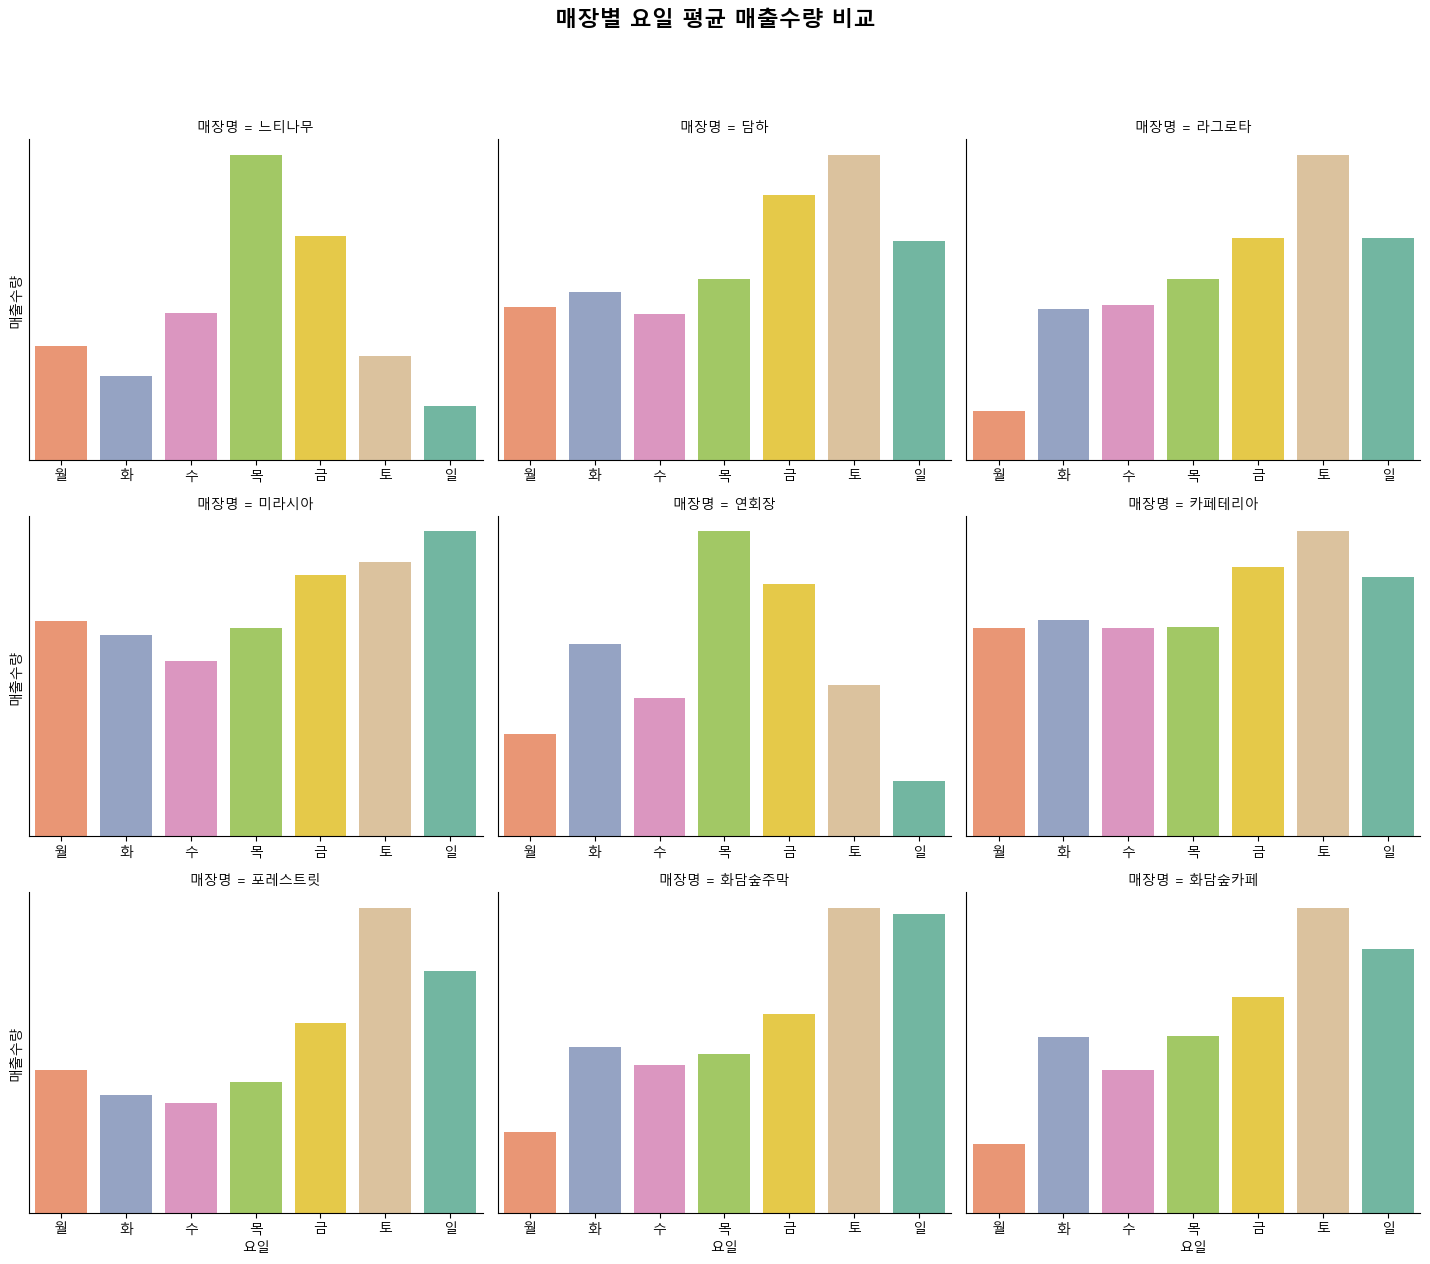

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

day_order = ['월', '화', '수', '목', '금', '토', '일']

g = sns.catplot(
    data=train, 
    x='요일', 
    y='매출수량', 
    col='매장명',         
    col_wrap=3,           
    kind='bar',           
    estimator='mean',     
    order=day_order,      
    errorbar=None,        
    height=4,             
    aspect=1.2,
    sharey=False,         
    sharex=False,         
    hue='요일',          
    dodge=False,
    palette='Set2'
)

g.fig.suptitle('매장별 요일 평균 매출수량 비교', y=1.05, fontsize=16, fontweight='bold')

plt.tight_layout() # 그래프 간격 예쁘게 자동 조절
plt.show()

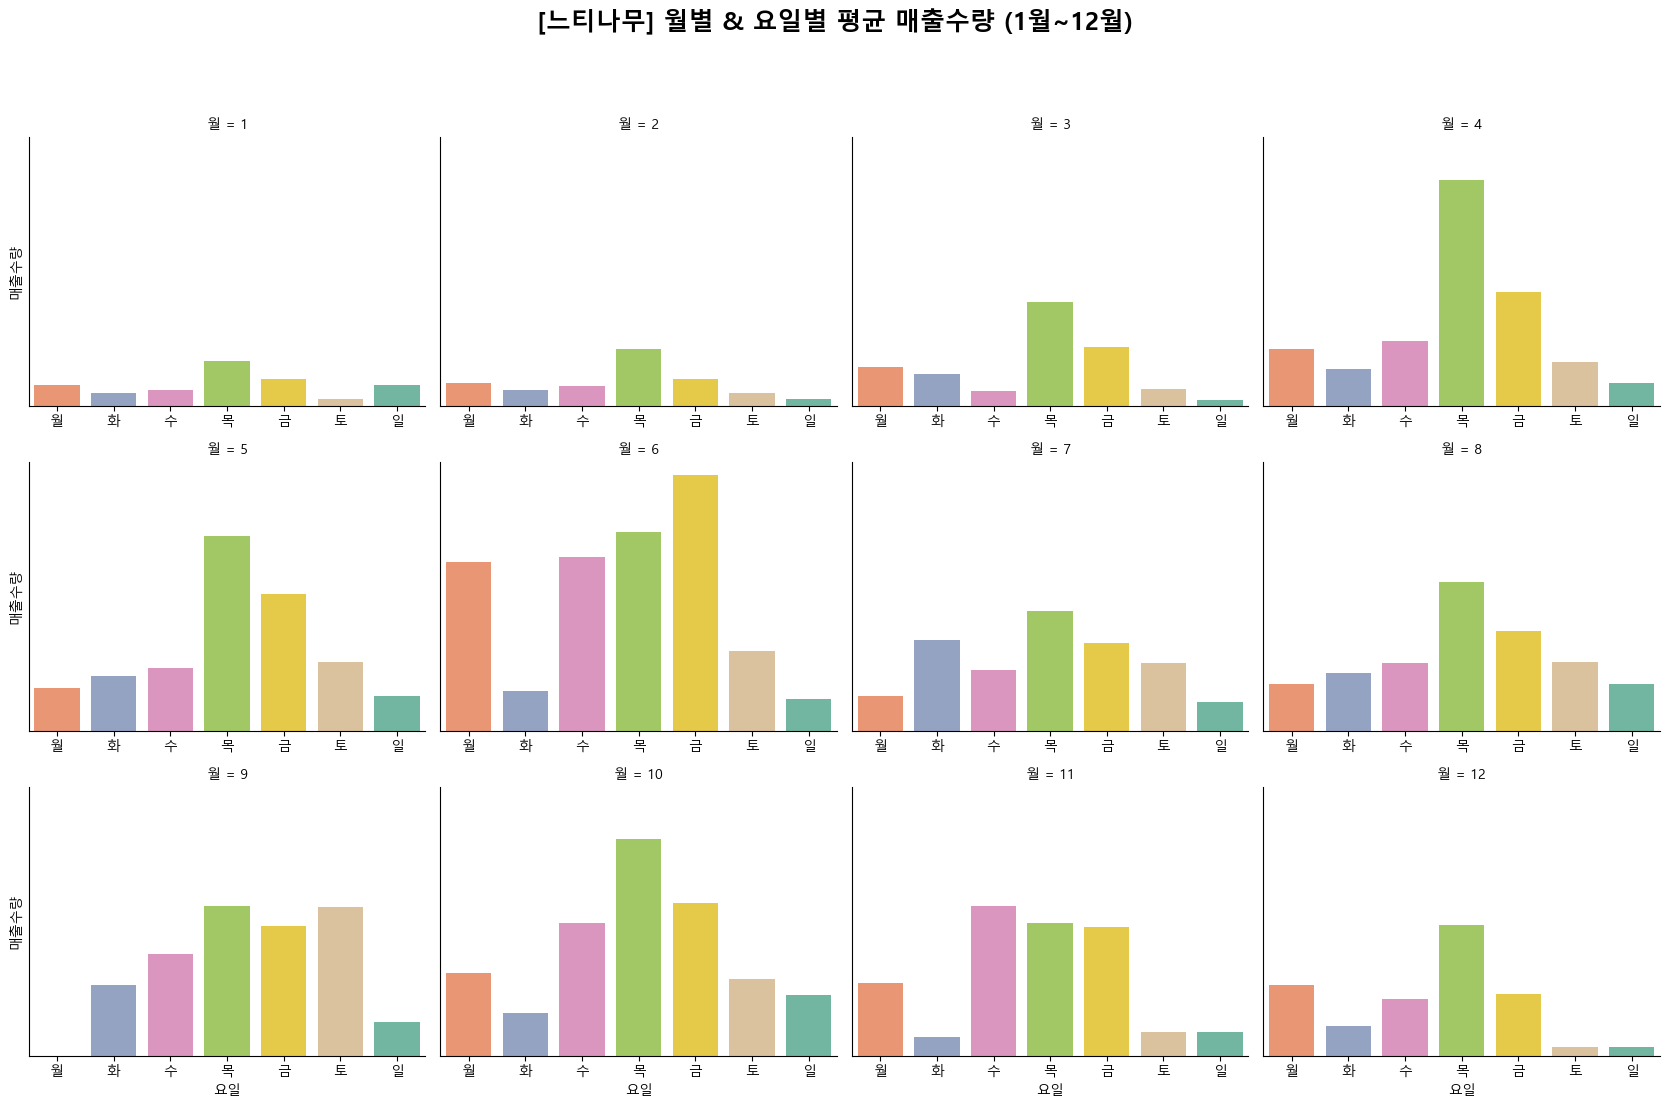

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '느티나무' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

'느티나무' 매장의 경우, 다른 월에 비해 1,2,3월은 비교적 매출이 작음을 알 수 있다.
또한 목요일이 기본적으로 매출이 많은 날임을 알 수 있다.
특이사항으로 9월에는 월요일 매출 평균이 0인것으로 보아, 9월에는 월요일이 정기휴무였음을 짐작할 수 있다. 

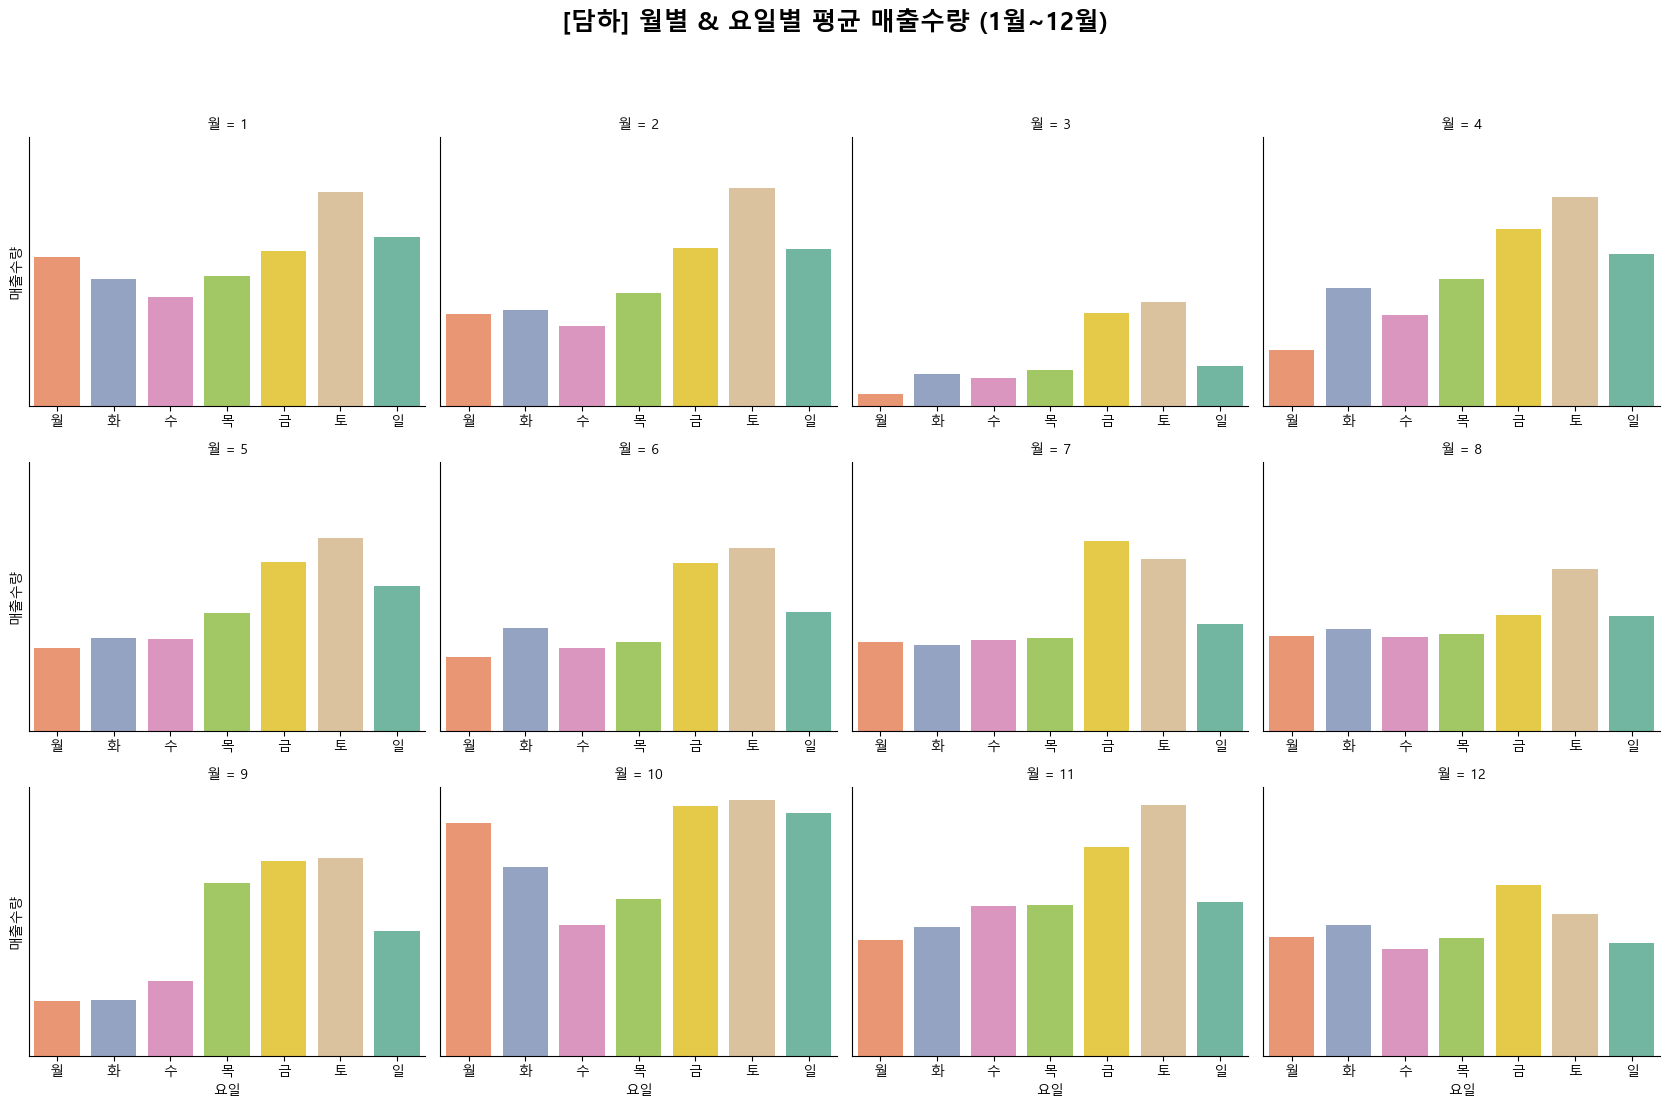

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '담하' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

담하 매장의 경우 기본적으로 토요일에 매출수량이 많으며, 
3월이 매출이 제일 작고, 10월이 매출이 제일 많음을 알 수 있다.

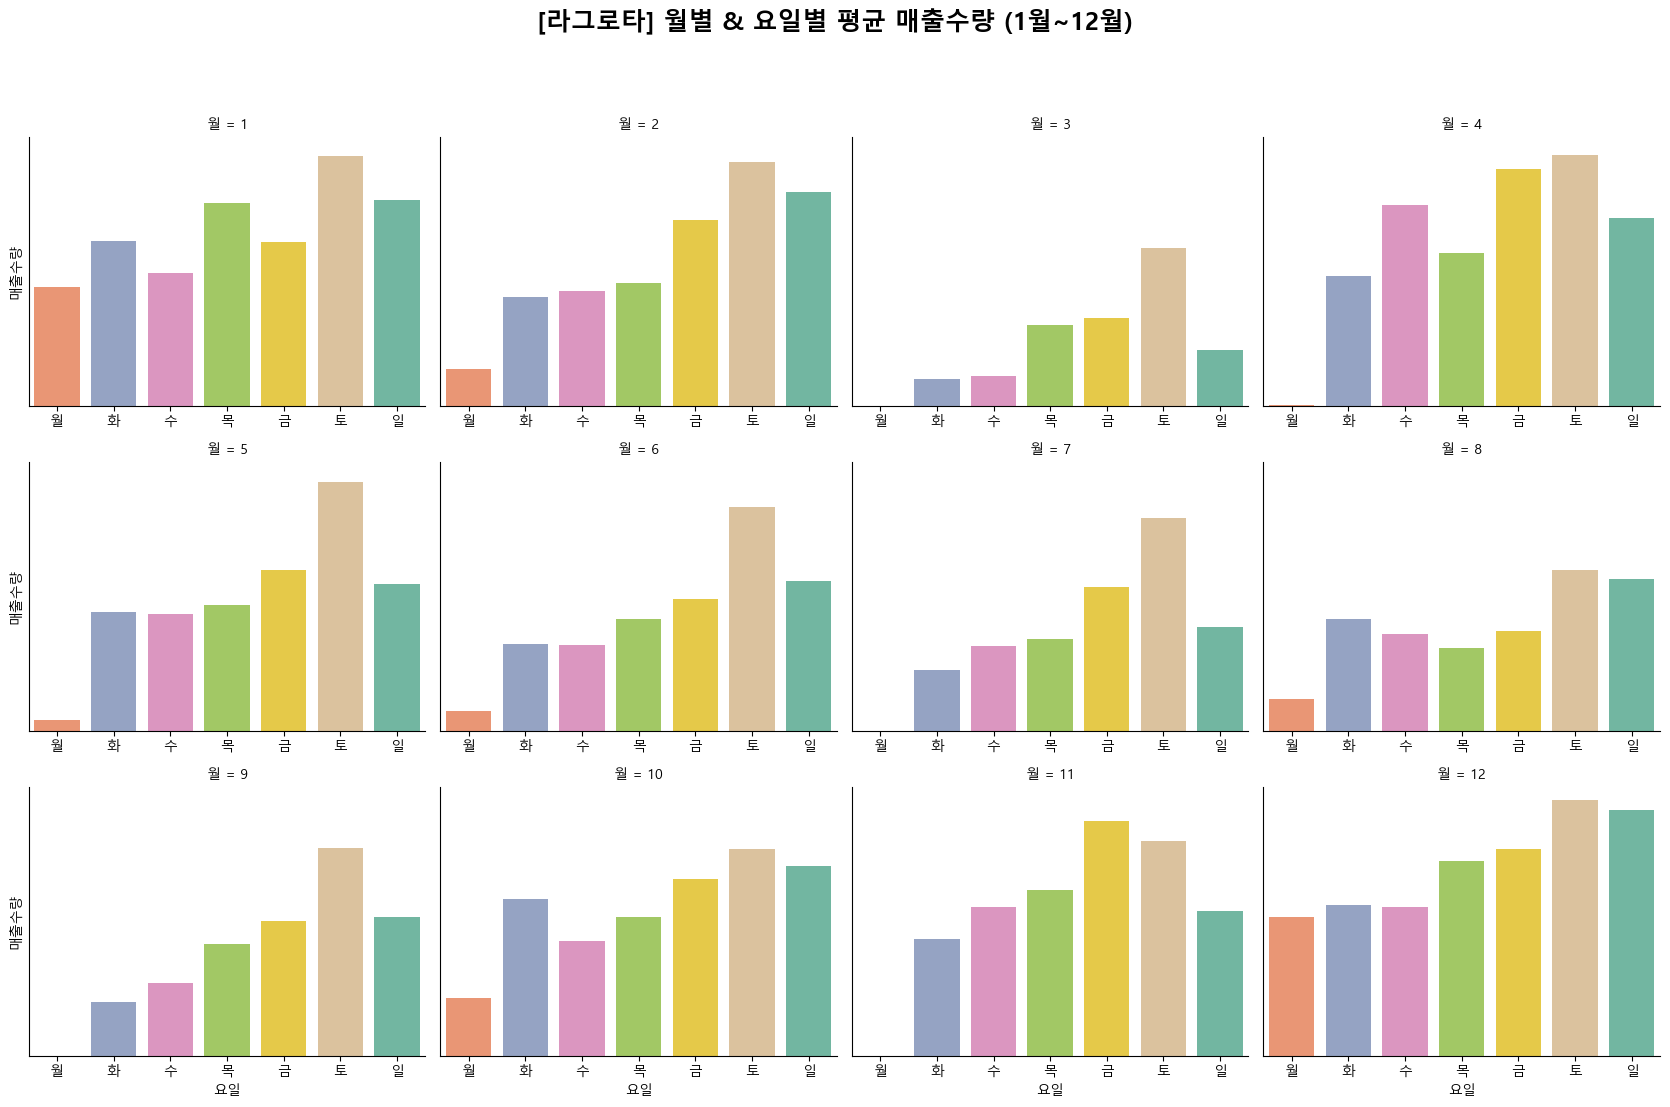

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '라그로타' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

라그로타의 경우 3,4,7,9,11월의 경우 월요일의 평균 매출수량이 0인것으로 보아, 월요일이 정기 휴무일이었음을 짐작할 수 있다.
또한 기본적으로 월요일의 매출수량이 가장 작은것으로 보아 월요일에 매장 방문객이 적거나, 운영시간이 짧은 날임을 짐작할 수 있다.
또한 평균적으로 토요일이 가장 매출수량이 높은 날임을 알 수 있다.

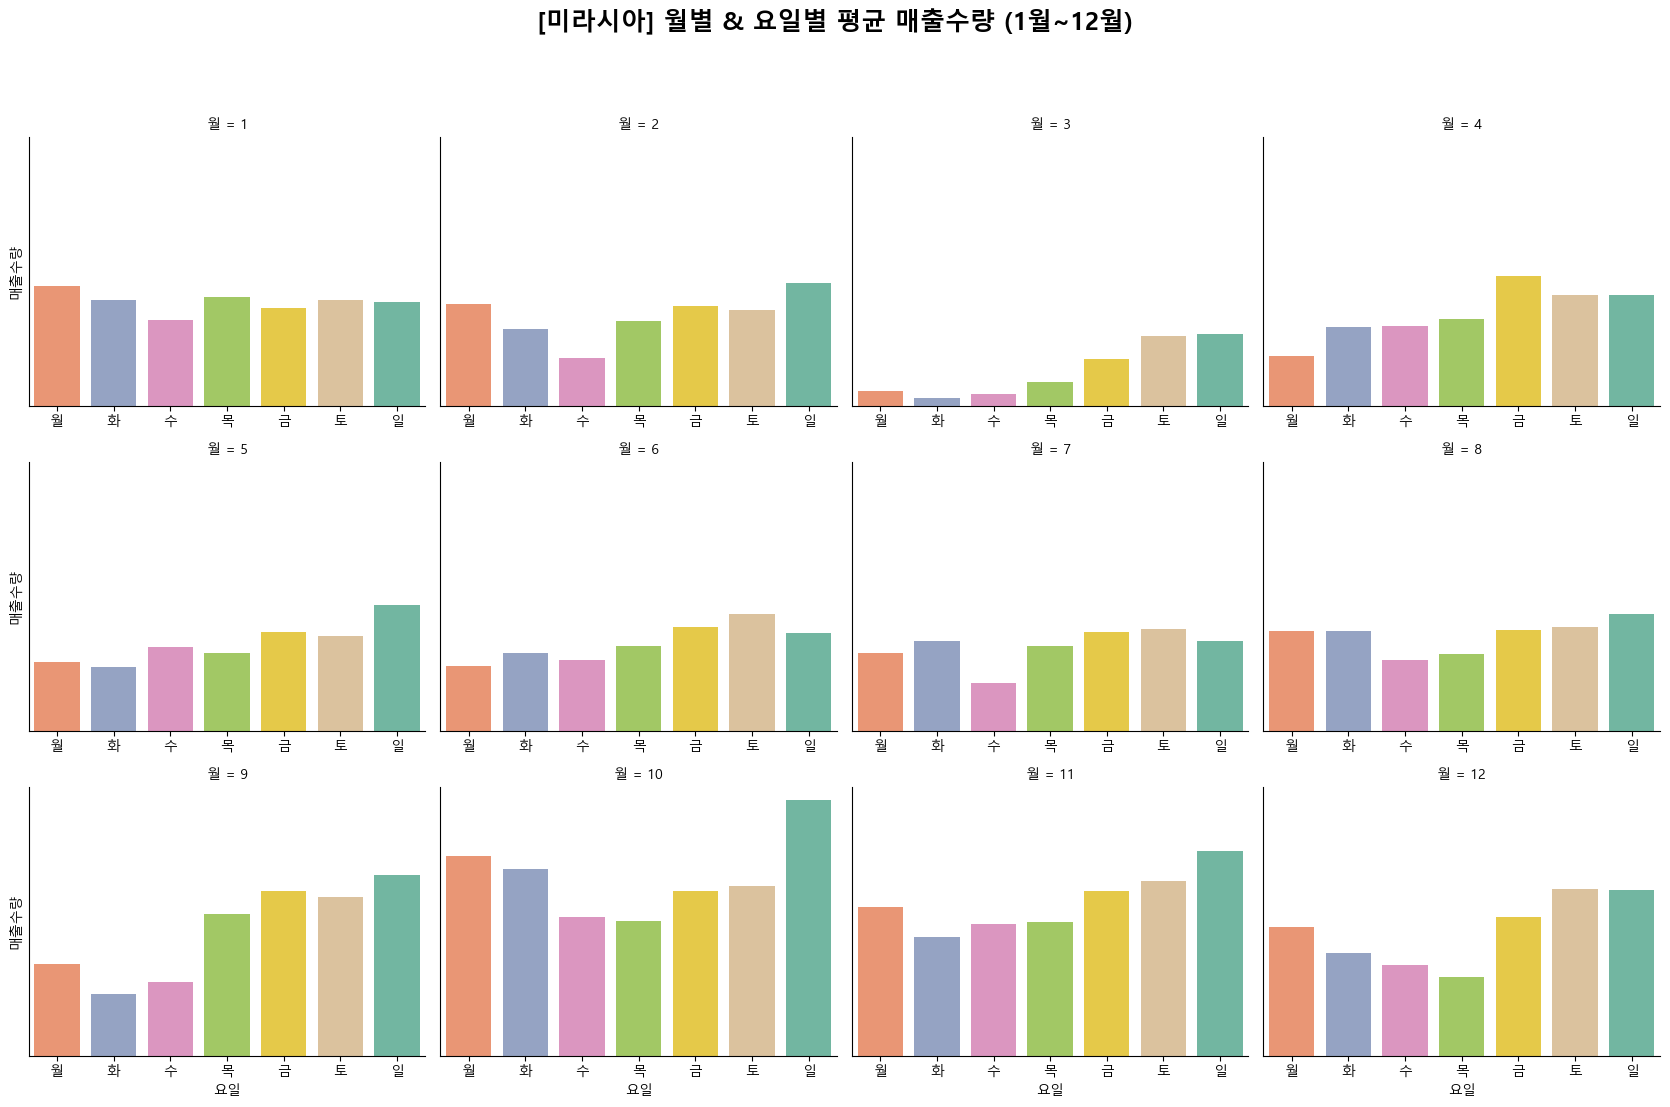

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '미라시아' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

미라시아 매장의 경우 3월이 가장 매출이 작으며, 10월의 매출수량이 가장 높음을 알 수 있다.
또한 평균적으로 수요일의 매출이 가장 작으며, 주말인 토,일에 매출수량이 높다.

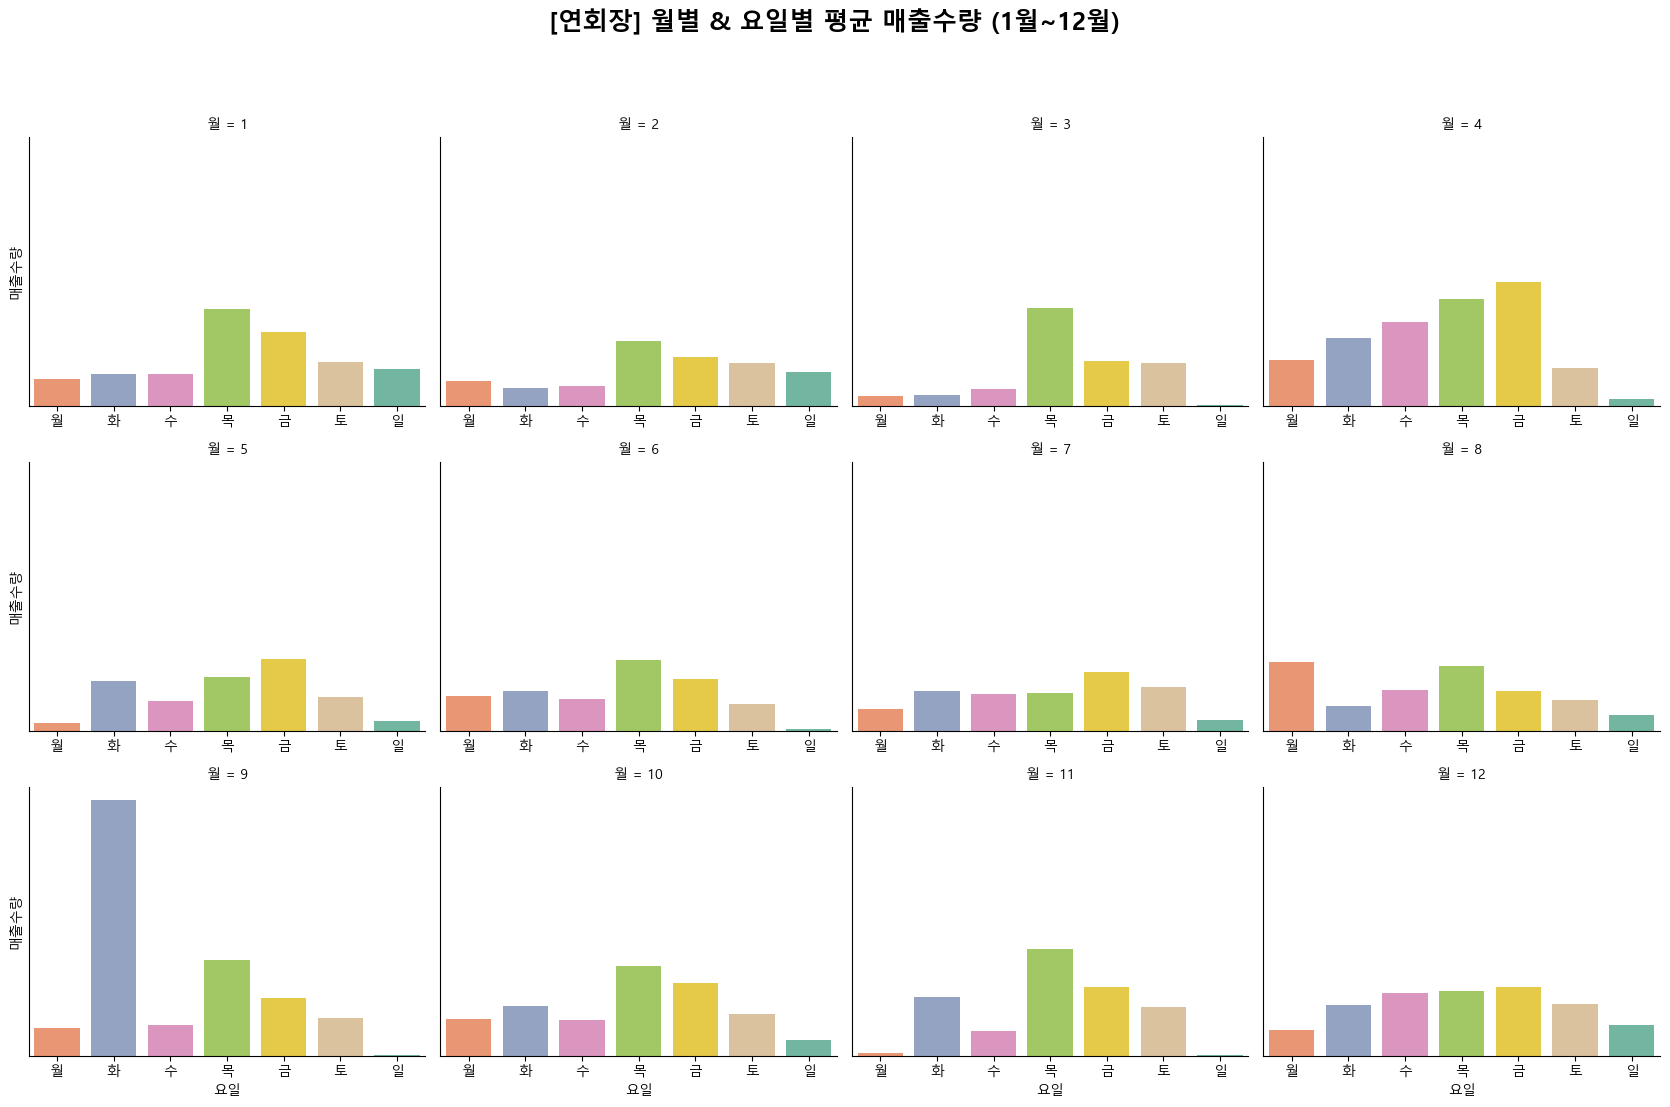

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '연회장' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

연회장의 경우 9월의 일요일에는 정기휴장을 했음을 짐작할 수 있으며, 화요일이 압도적으로 매출수량이 많은것으로 보아
9월의 화요일에 이상치가 섞여있거나, 특정 행사로 인해 화요일에 사람이 많이 몰렸음을 짐작할 수 있다. 
또한, 기본적으로 목요일에 매출수량이 높은 편임을 알 수 있다.

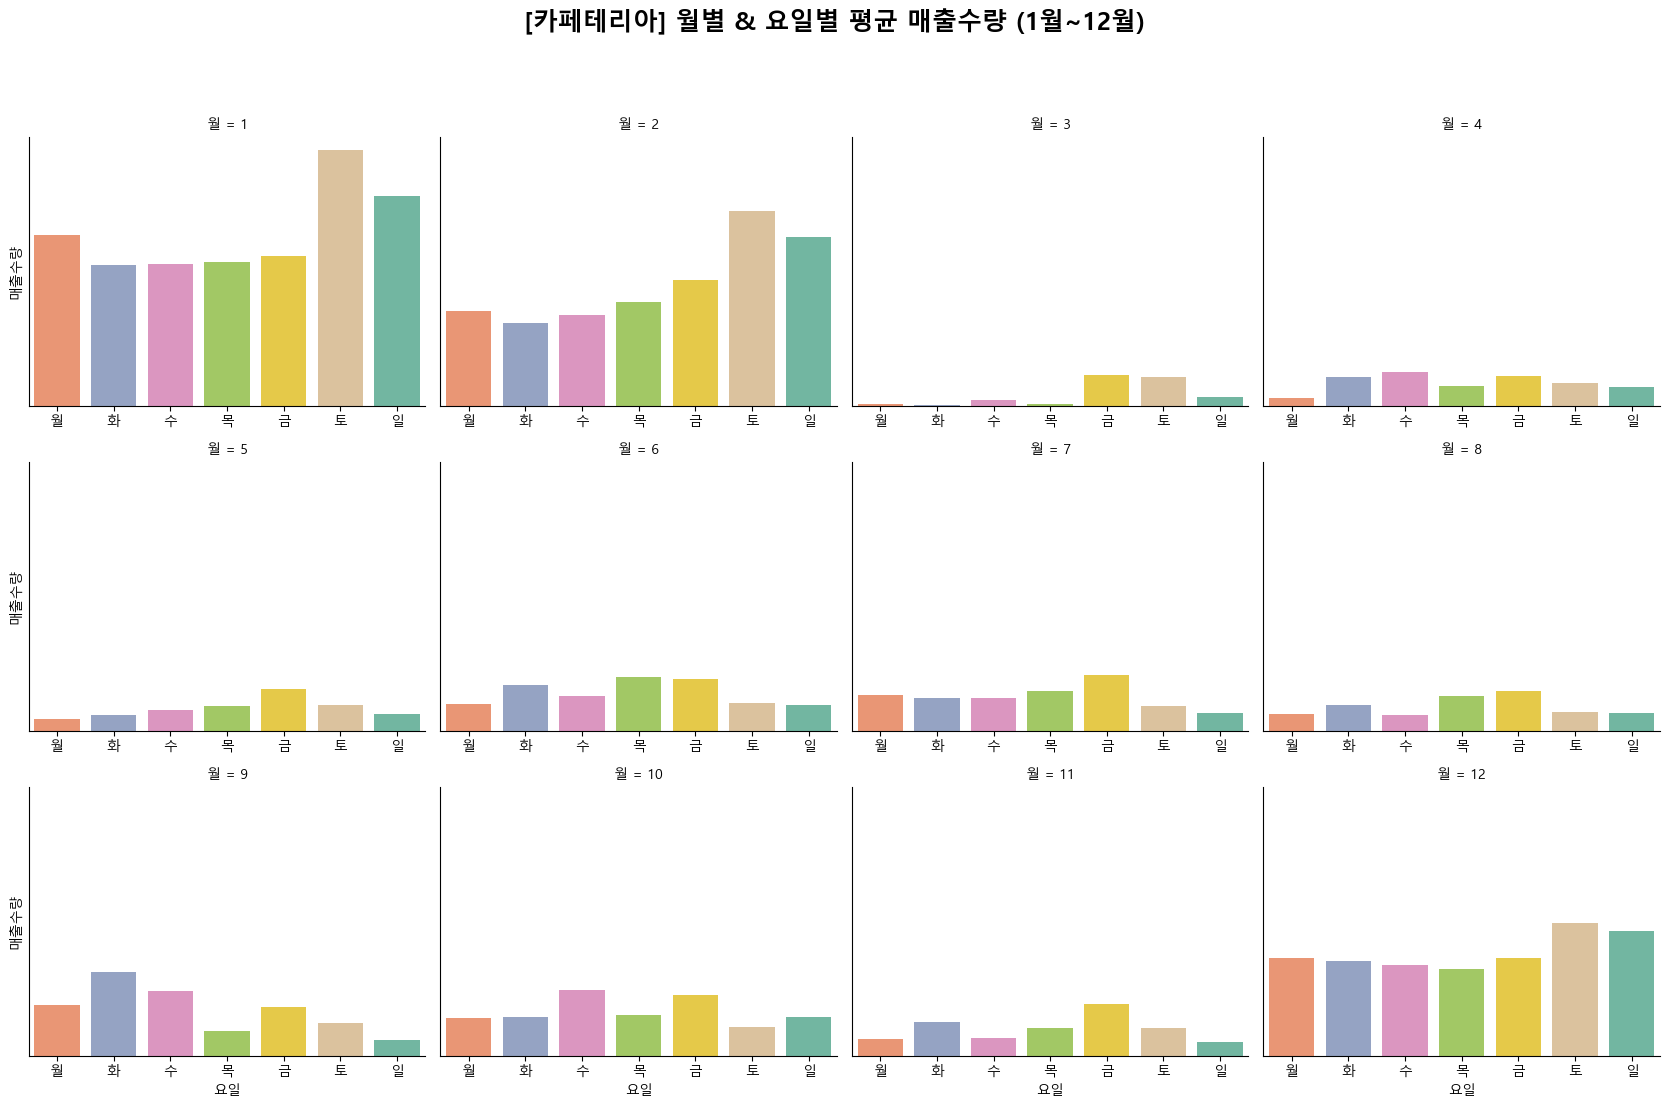

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '카페테리아' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

카페테리아의 경우 12,1,2월이 매출수량이 높고 나머지 월에는 매출수량이 낮음을 알 수 있다.
특히 3월의 매출이 가장 작음을 알 수 있다.

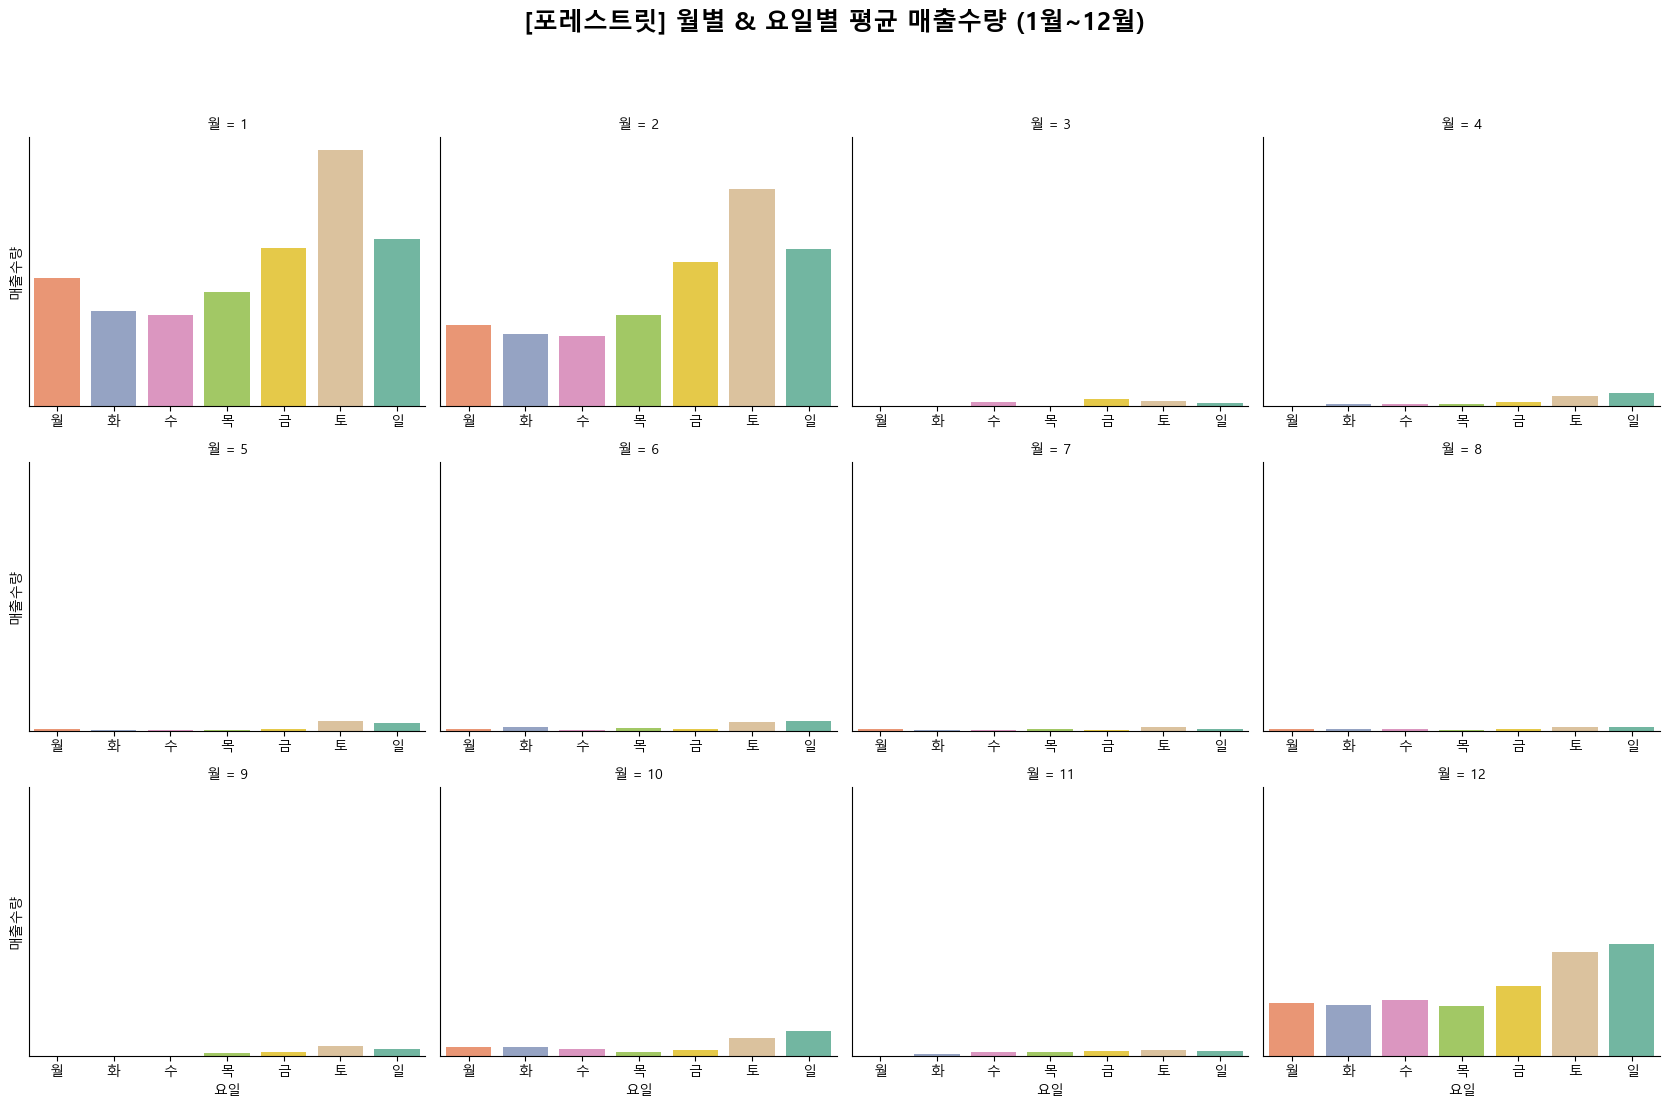

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '포레스트릿' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

포레스트릿의 경우 1,2,12월에 매출이 많고 나머지 월에는 거의 매출이 없음을 알 수 있다.
3월의 월,화,목/ 4월의 월/ 9월의 월,화,수/11월의 월요일은 매출이 아예 없는것으로 보아 휴장일임을 짐작할 수 있다.

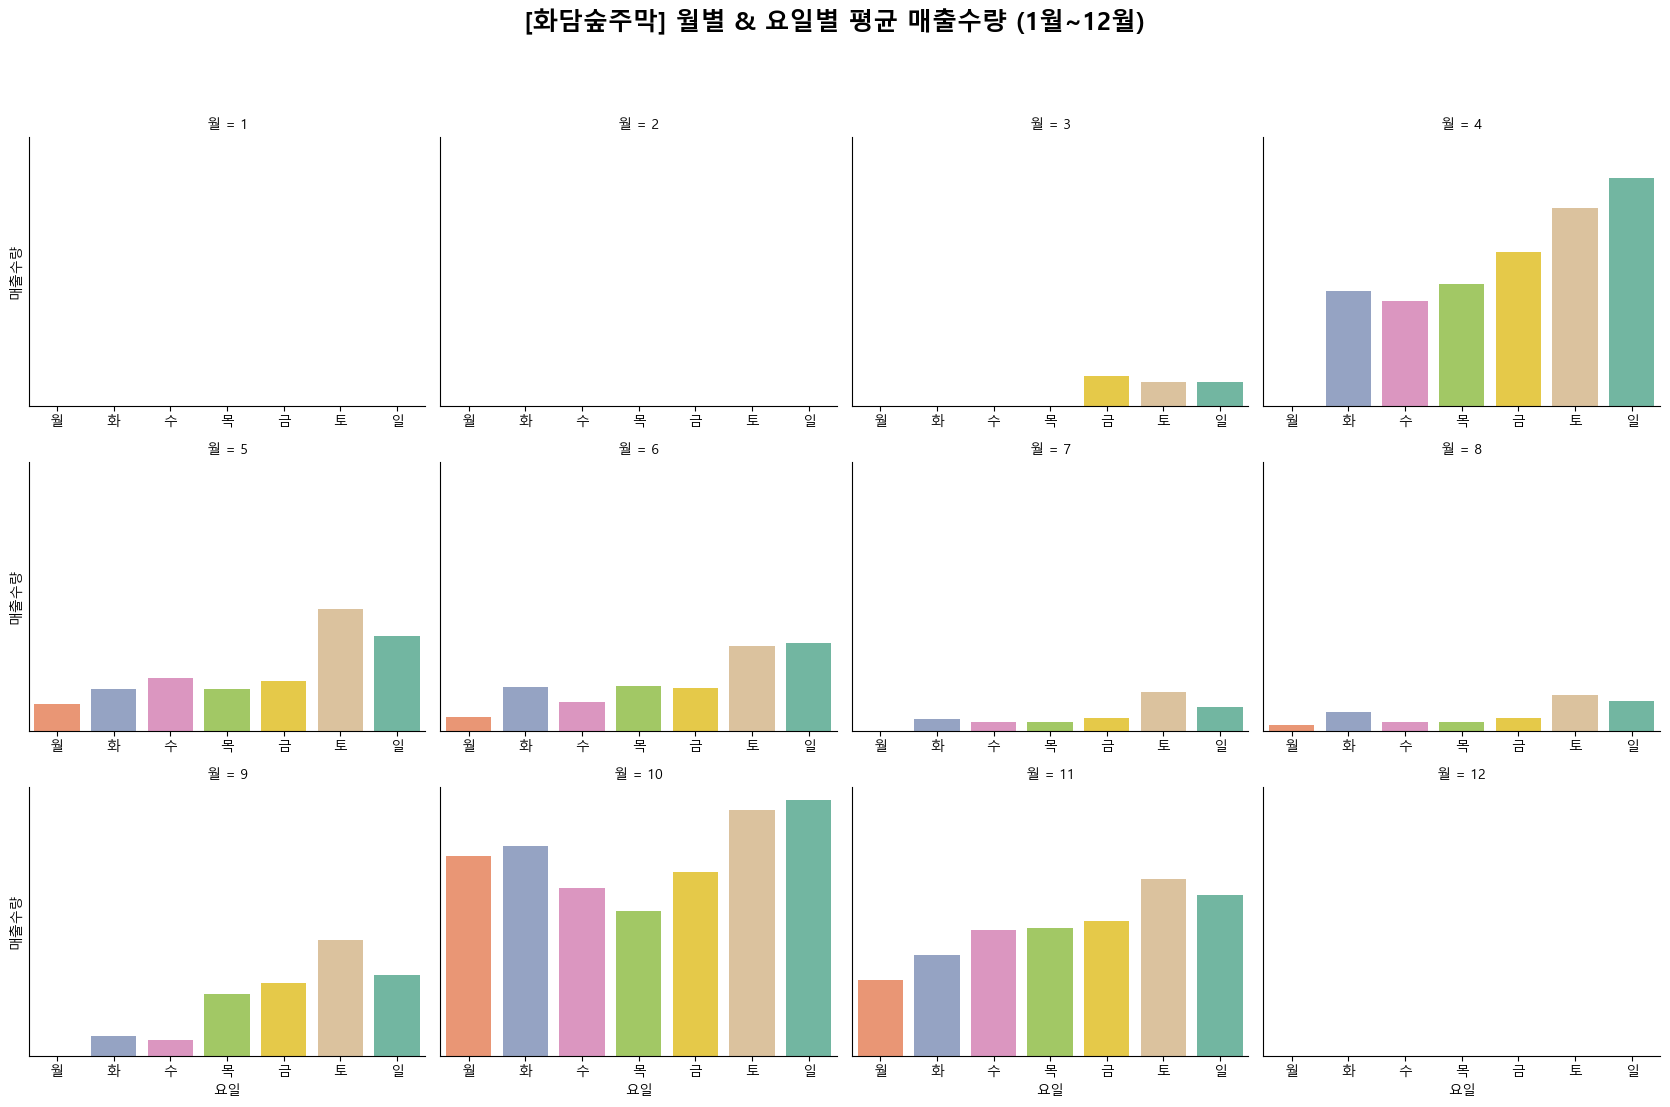

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '화담숲주막' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

화담숲주막의 경우, 1,2,12월은 아예 폐장함을 짐작할 수 있다.
또한 3월의 경우 금,토,일만 영업했음을 짐작할 수 있고, 4월의 경우 월요일 정기휴업, 7월의 경우 월요일 정기휴업, 9월의 경우 월요일 정기휴업을 했음을 짐작할 수 있다.

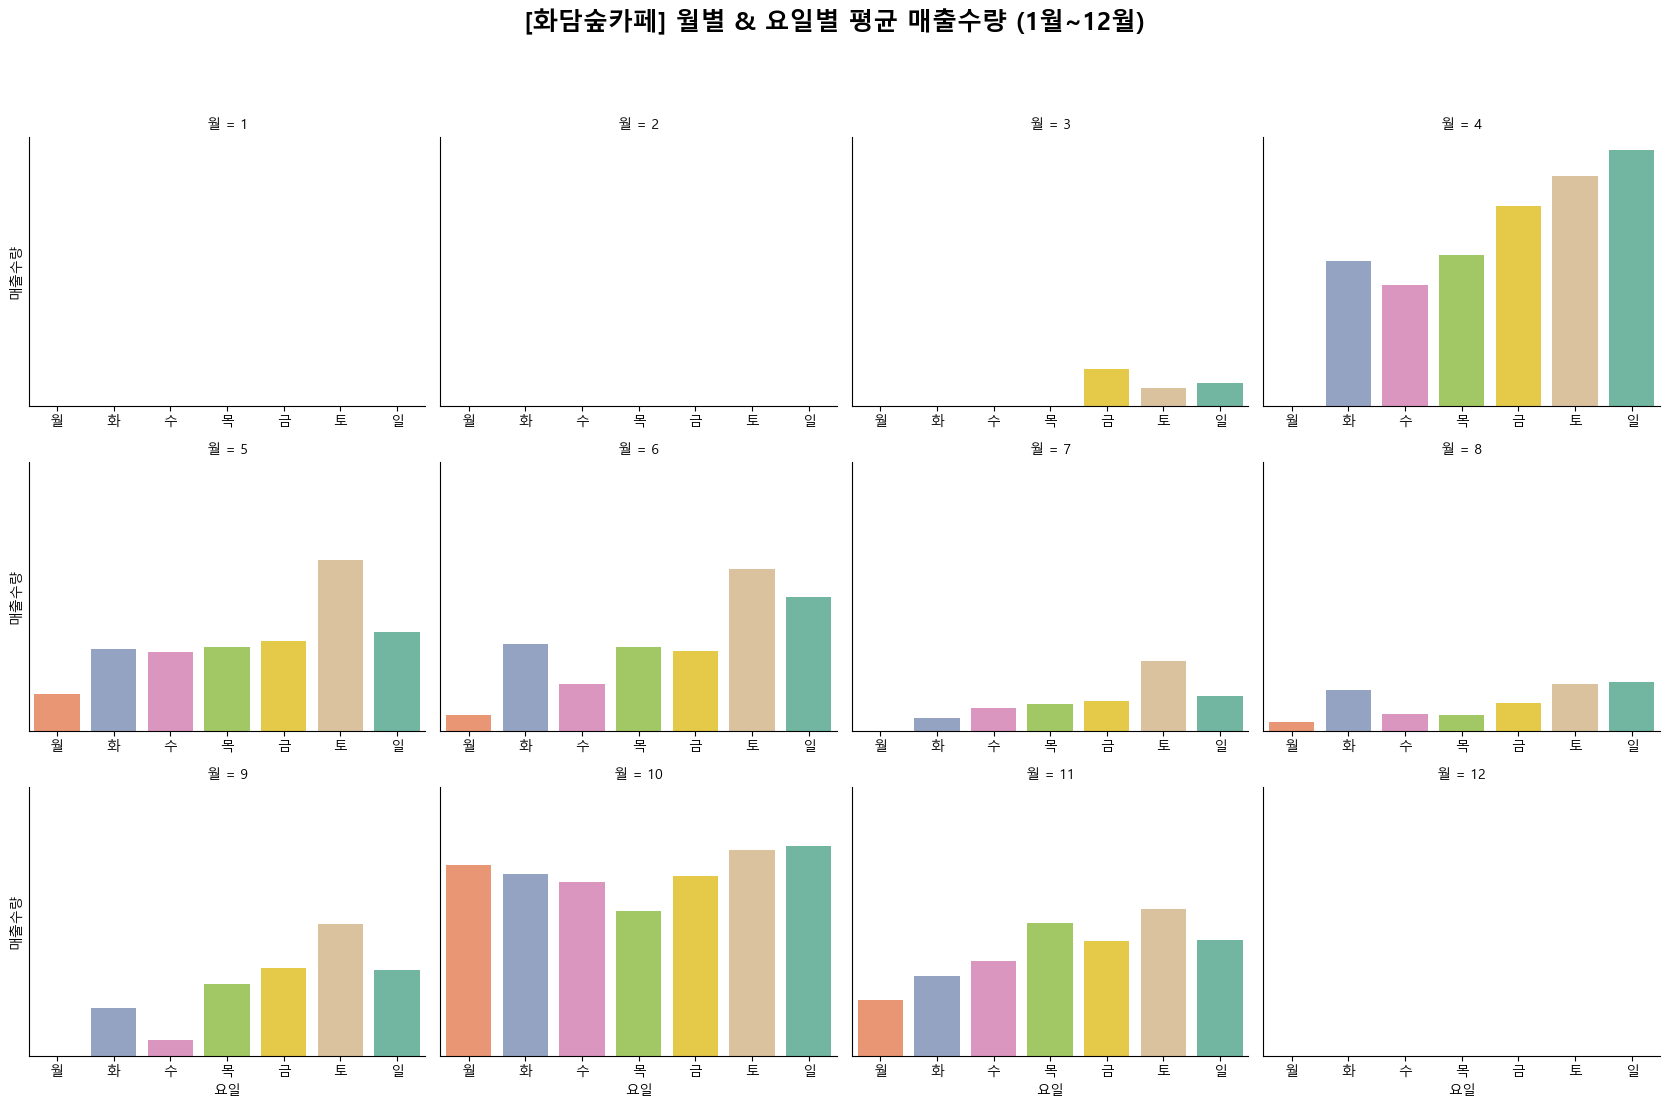

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 
day_order = ['월', '화', '수', '목', '금', '토', '일']

# -------------------- 2. 분석하고 싶은 매장  --------------------
target_store = '화담숲카페' 

store_data = train[train['매장명'] == target_store]

# -------------------- 3. 12개의 월별 그래프 그리기 --------------------
g = sns.catplot(
    data=store_data, 
    x='요일', 
    y='매출수량', 
    col='월',            
    col_wrap=4,          
    kind='bar',           
    estimator='mean',   
    order=day_order,      
    errorbar=None,        
    height=3.5,          
    aspect=1.2,       
    sharey=True,      
    sharex=False,
    hue='요일',          
    dodge=False,
    palette='Set2'       
)

# 전체 제목 달기
g.fig.suptitle(f'[{target_store}] 월별 & 요일별 평균 매출수량 (1월~12월)', y=1.05, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

화담숲카페도 화담숲주막과 마찬가지로 1,2,12월은 아예 폐장함을 짐작할 수 있다.
또한 3월의 경우 금,토,일만 영업했음을 짐작할 수 있고, 4월의 경우 월요일 정기휴업, 7월의 경우 월요일 정기휴업, 9월의 경우 월요일 정기휴업을 했음을 짐작할 수 있다.
이를 보아 화담숲카페와 화담숲주막의 정기휴업일은 같음을 짐작할 수 있다. 

In [23]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '느티나무'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [24]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '담하'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [25]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '라그로타'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [26]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '미라시아'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [27]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '연회장'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [28]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '카페테리아'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [29]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '포레스트릿'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [30]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '화담숲주막'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

In [31]:
%%capture
# 1. 매장별, 월별, 메뉴별 '총 매출수량' 집계하기
monthly_sales = train.groupby(['매장명', '월', '메뉴명'])['매출수량'].sum().reset_index()

# 2. 분석하고 싶은 매장 이름 지정 
target_store = '화담숲카페'
store_data = monthly_sales[monthly_sales['매장명'] == target_store]

print(f"========== 🏪 [{target_store}] 월별 Top 3 & Bottom 3 메뉴 ==========\n")

# 3. 해당 매장의 월별 데이터(1월~12월)를 순서대로 반복하며 출력
for month in sorted(store_data['월'].unique()):
    # 특정 월의 데이터만 필터링
    month_data = store_data[store_data['월'] == month]
    
    # 만약 해당 월에 영업을 안 해서 데이터가 없다면 건너뛰기
    if month_data.empty:
        continue
        
    # 매출수량을 기준으로 내림차순(가장 많이 팔린 순) 정렬
    sorted_data = month_data.sort_values(by='매출수량', ascending=False)
    
    # 위에서 3개(Top), 아래서 3개(Bottom) 뽑기
    top3 = sorted_data.head(3)
    bottom3 = sorted_data.tail(3)
    
    print(f"📅 {month}월")
    
    print("  🏆 [가장 많이 팔린 Top 3]")
    for _, row in top3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("  🚨 [가장 적게 팔린 Bottom 3]")
    for _, row in bottom3.iterrows():
        print(f"    - {row['메뉴명']} : {row['매출수량']:,}개")
        
    print("-" * 40)

화담숲주막, 화담숲카페 모두 1,2,12월의 각각의 메뉴의 매출수량의 총합이 모두 0이므로 폐장하는 기간임을 확신할 수 있다.

bottom 3에서 매출수량이 0개인 메뉴의 경우 시즌 메뉴일 가능성도 짐작할 수 있다.

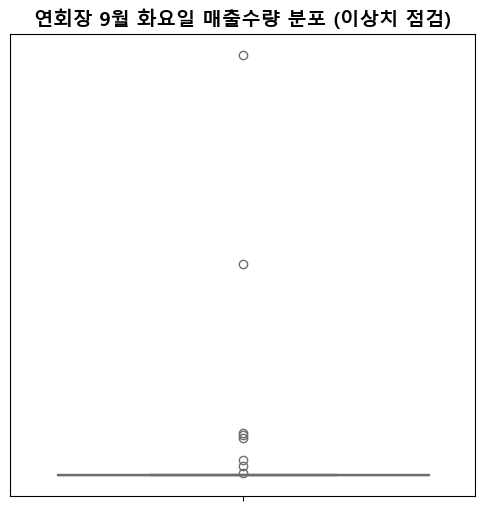

📊 [통계적 분석 결과]
- 정상적인 최대 매출 상한선(Upper Bound): 2.5개
- 상한선을 초과한 튀는 데이터 개수: 8건



In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 타겟 데이터 필터링 --------------------
# 매장명='연회장', 월=9, 요일='화' 인 데이터만 뽑아내기
target_data = train[(train['매장명'] == '연회장') & (train['월'] == 9) & (train['요일'] == '화')]

# -------------------- 2. 눈으로 확인: 박스플롯(Boxplot) --------------------
plt.figure(figsize=(6, 6))
sns.boxplot(data=target_data, y='매출수량', color='lightcoral')
plt.title('연회장 9월 화요일 매출수량 분포 (이상치 점검)', fontsize=14, fontweight='bold')
plt.show()

# -------------------- 3. 숫자로 확인: IQR 수식으로 이상치 찾기 --------------------
# Q1(하위 25%), Q3(상위 25%) 값 구하기
Q1 = target_data['매출수량'].quantile(0.25)
Q3 = target_data['매출수량'].quantile(0.75)
IQR = Q3 - Q1

# 정상 범주의 '상한선' 계산 (보통 Q3 + 1.5 * IQR을 기준으로 해!)
upper_bound = Q3 + 1.5 * IQR 

# 상한선을 뚫고 올라간 '비정상적으로 높은' 데이터만 골라내기
outliers = target_data[target_data['매출수량'] > upper_bound]

print(f"📊 [통계적 분석 결과]")
print(f"- 정상적인 최대 매출 상한선(Upper Bound): {upper_bound:.1f}개")
print(f"- 상한선을 초과한 튀는 데이터 개수: {len(outliers)}건\n")


In [33]:
%%capture
if not outliers.empty:
    print("🚨 발견된 주요 이상치 데이터 (매출수량 높은 순):")
    # 어떤 날짜에, 어떤 메뉴가 그렇게 많이 팔렸는지 표로 출력
    display(outliers[['영업일자', '메뉴명', '매출수량']].sort_values(by='매출수량', ascending=False).head(10))
else:
    print("✅ 통계적으로 범위를 크게 벗어난 이상치는 없습니다.")

위 결과를 보아 2023-09-05,2023-09-12,2023-09-19,2023-09-26에 연회가 있었음을 짐작할 수 있다.
해당 일자에 매출수량이 비정상적으로 높게 찍힌 메뉴들이 존재한다.

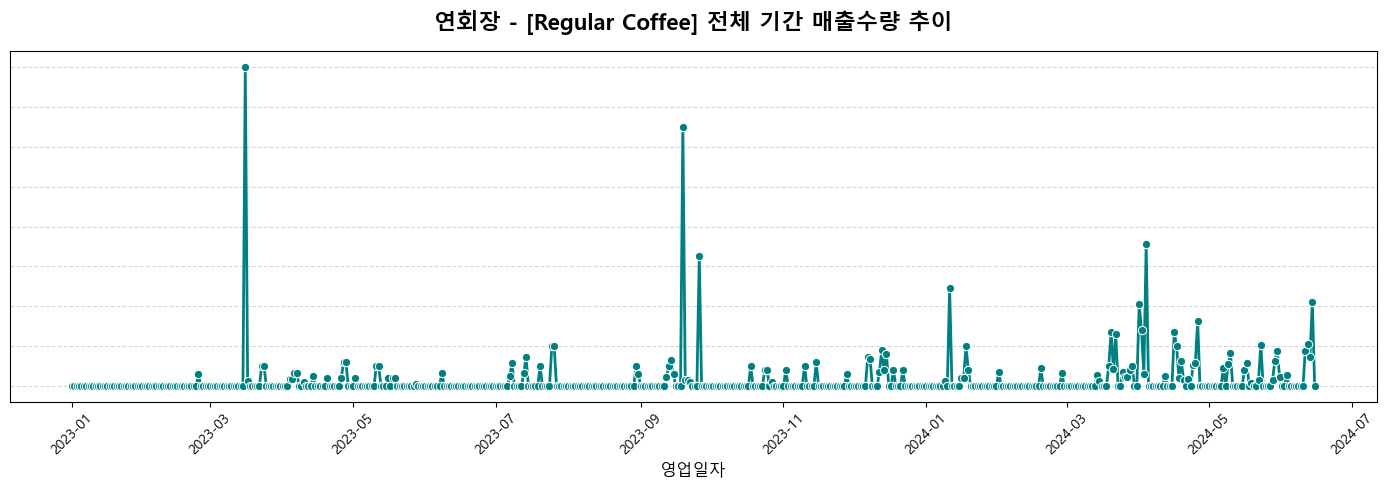

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- 1. 한글 폰트 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# -------------------- 2. 타겟 데이터 필터링 & 정렬 --------------------
# 매장명이 '연회장'이고 메뉴명이 'Regular Coffee'인 데이터만 추출
target_data = train[(train['매장명'] == '연회장') & (train['메뉴명'] == 'Regular Coffee')]

# 꺾은선이 꼬이지 않도록 영업일자(시간) 순으로 오름차순 정렬! (매우 중요)
target_data = target_data.sort_values(by='영업일자')

# -------------------- 3. 꺾은선 그래프 그리기 --------------------
plt.figure(figsize=(14, 5)) # 가로로 길게 설정해서 날짜를 넓게 보기

# marker='o'를 넣으면 꺾이는 부분마다 동그란 점이 찍혀서 가독성이 좋아져
sns.lineplot(data=target_data, x='영업일자', y='매출수량', marker='o', color='teal', linewidth=2)

# -------------------- 4. 그래프 디테일 꾸미기 --------------------
plt.title('연회장 - [Regular Coffee] 전체 기간 매출수량 추이', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('영업일자', fontsize=12)
plt.ylabel('매출수량', fontsize=12)

# X축 날짜 글씨가 길어서 서로 겹칠 수 있으니 45도 기울여주기
plt.xticks(rotation=45) 

# 배경에 연한 격자무늬(Grid)를 깔아줘서 수치 읽기 편하게 만들기
plt.grid(True, axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

연회가 있으면 사람들이 가장 흔하게 소비하는 메뉴인 regular coffee의 매출수량이 비정상적으로 증가할 것이라 생각하였다.
위 그래프에서 지나치게 높게 매출수량이 찍힌 날들은 연회가 있었던 날일 것이다.

📊 [리조트 전체 기준] 휴일 유형별 하루 평균 총매출수량


,휴일_유형,해당_일수,일일_평균_총매출
0,1. 빨간날,29,3157.275862
1,2. 샌드위치 데이,3,1532.666667
2,3. 빨간날 전날,15,2664.600000
3,4. 빨간날 다음날,15,1646.400000
4,5. 일반 주말,137,2614.197080
5,6. 일반 평일,333,1726.759760


C:\Users\ygjun\AppData\Local\Temp\ipykernel_5428\1885582083.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


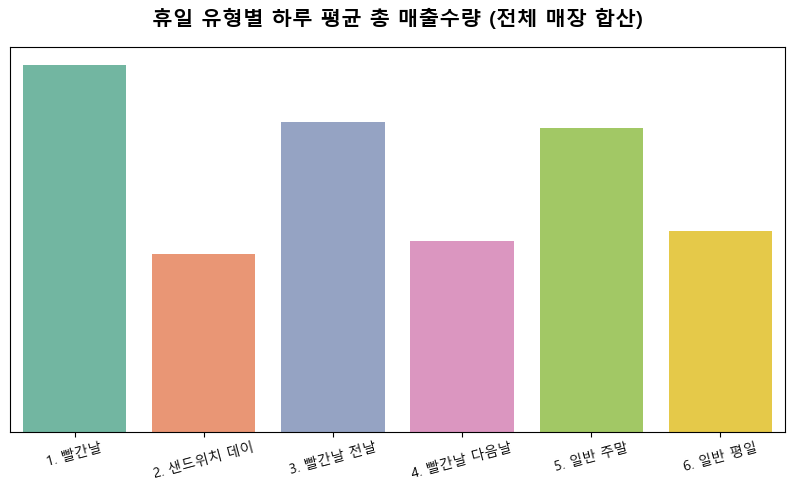

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- 1. 기본 세팅 --------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

HOLIDAYS = {
    '2023-01-21','2023-01-22','2023-01-23','2023-01-24','2023-03-01','2023-05-05','2023-05-27','2023-05-29',
    '2023-06-06','2023-08-15','2023-09-28','2023-09-29','2023-09-30','2023-10-01','2023-10-02','2023-10-03',
    '2023-10-09','2023-12-25','2024-01-01','2024-02-09','2024-02-10','2024-02-11','2024-02-12','2024-03-01',
    '2024-04-10','2024-05-05','2024-05-06','2024-05-15','2024-06-06','2024-08-15','2024-09-16','2024-09-17',
    '2024-09-18','2024-10-03','2024-10-09','2024-12-25','2025-01-01','2025-01-28','2025-01-29','2025-01-30',
    '2025-03-01','2025-05-05','2025-05-06'
}

# 날짜 형식으로 변환 (계산을 위해)
dates = pd.to_datetime(train['영업일자'])
holidays_dt = pd.to_datetime(list(HOLIDAYS))

# -------------------- 2. 각 날짜별 참/거짓(Boolean) 마스크 생성 --------------------
is_red = dates.isin(holidays_dt)
is_weekend = dates.dt.weekday >= 5
is_rest = is_red | is_weekend # 빨간날이거나 주말인 '쉬는 날'

# 어제와 내일의 속성 계산
dates_yesterday = dates - pd.Timedelta(days=1)
dates_tomorrow = dates + pd.Timedelta(days=1)

tomorrow_is_red = dates_tomorrow.isin(holidays_dt)
yesterday_is_red = dates_yesterday.isin(holidays_dt)

tomorrow_is_rest = tomorrow_is_red | (dates_tomorrow.dt.weekday >= 5)
yesterday_is_rest = yesterday_is_red | (dates_yesterday.dt.weekday >= 5)

# -------------------- 3. 조건 리스트 만들기 (np.select 활용) --------------------
# 💡 위에서부터 아래로 순서대로 검사하며, 먼저 걸리는 조건이 적용됨!
cond1 = is_red
cond2 = (~is_rest) & yesterday_is_rest & tomorrow_is_rest  # 샌드위치 데이 (가장 구체적인 조건이므로 우선순위 UP!)
cond3 = (~is_red) & tomorrow_is_red                        # 빨간날 전날
cond4 = (~is_red) & yesterday_is_red                       # 빨간날 다음날
cond5 = is_weekend                                         # 앞 케이스들에 안 걸린 순수 주말

conditions = [cond1, cond2, cond3, cond4, cond5]
choices = ['1. 빨간날', '2. 샌드위치 데이', '3. 빨간날 전날', '4. 빨간날 다음날', '5. 일반 주말']

# 모든 조건에 해당하지 않으면 '6. 일반 평일'로 자동 분류
train['휴일_유형'] = np.select(conditions, choices, default='6. 일반 평일')
# -------------------------------------------------------------------------
# 4: 날짜별(영업일자)로 모든 매장/메뉴의 매출수량을 싹 다 더하기 (일일 총매출)
# (이때 '휴일_유형' 정보도 잃어버리지 않게 같이 묶음)
# -------------------------------------------------------------------------
daily_sales = train.groupby(['영업일자', '휴일_유형'])['매출수량'].sum().reset_index()
# -> 이제 daily_sales는 [영업일자, 휴일_유형, (그날의)총매출수량] 형태가 됨!

# -------------------------------------------------------------------------
# 5: 위에서 구한 '일일 총매출'을 휴일 유형별로 묶어서 평균(mean) 내기
# -------------------------------------------------------------------------
holiday_summary = daily_sales.groupby('휴일_유형').agg(
    해당_일수=('영업일자', 'nunique'),     # 그 유형에 해당하는 날짜가 총 며칠인지
    일일_평균_총매출=('매출수량', 'mean')   # 그 유형의 하루 평균 총 매출수량
).reset_index()

print("📊 [리조트 전체 기준] 휴일 유형별 하루 평균 총매출수량")
display(holiday_summary.sort_values(by='휴일_유형'))

# -------------------------------------------------------------------------
# 3단계: 정확해진 데이터로 다시 막대그래프 그리기
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=daily_sales, # 원본(train)이 아니라 1단계에서 만든 일별 요약 데이터를 씀!
    x='휴일_유형', 
    y='매출수량', 
    order=['1. 빨간날', '2. 샌드위치 데이', '3. 빨간날 전날', '4. 빨간날 다음날', '5. 일반 주말', '6. 일반 평일'],
    palette='Set2',
    errorbar=None
)

plt.title('휴일 유형별 하루 평균 총 매출수량 (전체 매장 합산)', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('하루 평균 총 매출수량')
plt.xlabel('')
plt.xticks(rotation=15)
plt.show()

빨간날과 빨간날 전날, 일반주말이 평균적으로 매출수량이 높은 것을 알 수 있다. 